In [102]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

In [103]:
df = pd.read_csv('email.csv')
print('Shape:', df.shape)
df.head()

Shape: (5573, 2)


,Category,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [104]:
print('Missing values per column:')
print(df.isnull().sum())
print(f'\nTotal NaN values: {df.isnull().sum().sum()}')

Missing values per column:
Category    0
Message     0
dtype: int64

Total NaN values: 0


In [106]:
# Run this first to see your actual column names
print(df.columns.tolist())
print(df.head(2))

['Category', 'Message']
  Category                                            Message
0      ham  Go until jurong point, crazy.. Available only ...
1      ham                      Ok lar... Joking wif u oni...


In [107]:
# Rename to lowercase standard names
df.rename(columns={'Category': 'category', 'Message': 'message'}, inplace=True)

# Drop rows where message or category is NaN
df.dropna(subset=['message', 'category'], inplace=True)

# Remove duplicates
df.drop_duplicates(inplace=True)

# Strip whitespace
df['message']  = df['message'].str.strip()
df['category'] = df['category'].str.strip().str.lower()

# Drop empty messages
df = df[df['message'] != '']
df.reset_index(drop=True, inplace=True)

print('Shape after cleaning:', df.shape)
print('\nCategory counts:')
print(df['category'].value_counts())

Shape after cleaning: (5158, 2)

Category counts:
category
ham               4516
spam               641
{"mode":"full"       1
Name: count, dtype: int64


In [108]:
df['label'] = df['category'].map({'spam': 1, 'ham': 0})

# Drop rows with unexpected category values
df.dropna(subset=['label'], inplace=True)
df['label'] = df['label'].astype(int)

print('Label distribution:')
print(df['label'].value_counts())

Label distribution:
label
0    4516
1     641
Name: count, dtype: int64


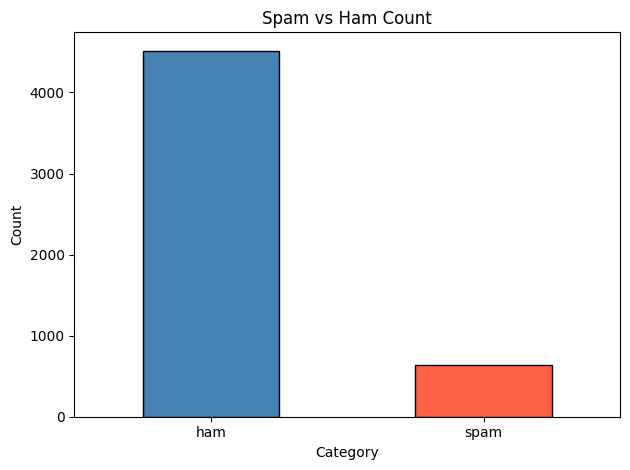

In [109]:
df['category'].value_counts().plot(
    kind='bar', color=['steelblue', 'tomato'],
    title='Spam vs Ham Count', edgecolor='black'
)
plt.xlabel('Category')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [110]:
vectorizer = TfidfVectorizer(
    stop_words='english',   # remove common words
    max_features=5000,      # keep top 5000 words
    ngram_range=(1, 2)      # unigrams + bigrams
)

X = vectorizer.fit_transform(df['message'])
y = df['label']

print('Feature matrix shape:', X.shape)

Feature matrix shape: (5157, 5000)


In [111]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('Training samples:', X_train.shape[0])
print('Testing  samples:', X_test.shape[0])

Training samples: 4125
Testing  samples: 1032


In [112]:
model = MultinomialNB(alpha=1.0)   # alpha = Laplace smoothing
model.fit(X_train, y_train)
print('Model trained successfully ✅')

Model trained successfully ✅


In [113]:
y_pred = model.predict(X_test)

acc = accuracy_score(y_test, y_pred)
print(f'Accuracy: {acc * 100:.2f}%\n')
print(classification_report(y_test, y_pred, target_names=['Ham', 'Spam']))

Accuracy: 97.38%

              precision    recall  f1-score   support

         Ham       0.97      1.00      0.99       904
        Spam       1.00      0.79      0.88       128

    accuracy                           0.97      1032
   macro avg       0.99      0.89      0.93      1032
weighted avg       0.97      0.97      0.97      1032



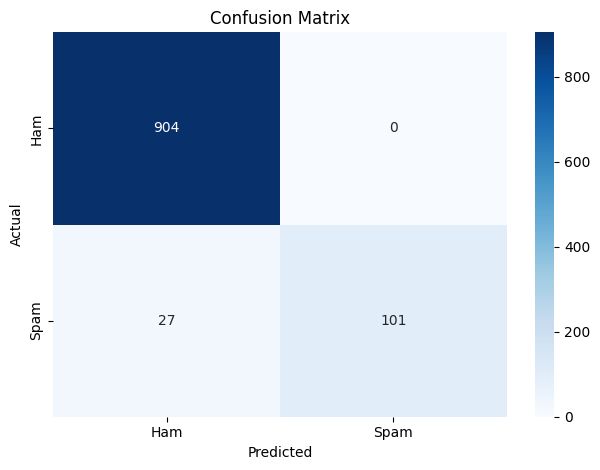

In [114]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['Ham', 'Spam'],
    yticklabels=['Ham', 'Spam']
)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

In [115]:
feature_names = vectorizer.get_feature_names_out()
log_odds = model.feature_log_prob_[1] - model.feature_log_prob_[0]

top_spam = np.argsort(log_odds)[-10:][::-1]
top_ham  = np.argsort(log_odds)[:10]

print('Top 10 SPAM words:')
for i in top_spam:
    print(f'  {feature_names[i]:<20} log-odds: {log_odds[i]:+.3f}')

print('\nTop 10 HAM words:')
for i in top_ham:
    print(f'  {feature_names[i]:<20} log-odds: {log_odds[i]:+.3f}')

Top 10 SPAM words:
  claim                log-odds: +3.222
  prize                log-odds: +3.039
  www                  log-odds: +2.951
  150p                 log-odds: +2.858
  uk                   log-odds: +2.784
  service              log-odds: +2.614
  18                   log-odds: +2.583
  tone                 log-odds: +2.552
  guaranteed           log-odds: +2.546
  1000                 log-odds: +2.499

Top 10 HAM words:
  gt                   log-odds: -3.212
  lt                   log-odds: -3.199
  lt gt                log-odds: -3.110
  lor                  log-odds: -3.052
  da                   log-odds: -3.028
  ok                   log-odds: -3.021
  come                 log-odds: -2.917
  home                 log-odds: -2.745
  ll                   log-odds: -2.712
  oh                   log-odds: -2.705


In [116]:
def predict_email(text):
    vec  = vectorizer.transform([text])
    pred = model.predict(vec)[0]
    prob = model.predict_proba(vec)[0]
    label = '🚨 SPAM' if pred == 1 else '✅ HAM'
    print(f'Email  : {text}')
    print(f'Result : {label}  (Ham: {prob[0]*100:.1f}%  |  Spam: {prob[1]*100:.1f}%)\n')

In [117]:
predict_email("Congratulations! You've won a free iPhone. Click here to claim now!")
predict_email("Hi, the meeting is scheduled for 3 PM tomorrow. Please confirm.")
predict_email("URGENT: Your bank account has been compromised. Verify immediately.")
predict_email("Please review the attached report and share your feedback by Friday.")

Email  : Congratulations! You've won a free iPhone. Click here to claim now!
Result : 🚨 SPAM  (Ham: 26.7%  |  Spam: 73.3%)

Email  : Hi, the meeting is scheduled for 3 PM tomorrow. Please confirm.
Result : ✅ HAM  (Ham: 98.8%  |  Spam: 1.2%)

Email  : URGENT: Your bank account has been compromised. Verify immediately.
Result : ✅ HAM  (Ham: 61.0%  |  Spam: 39.0%)

Email  : Please review the attached report and share your feedback by Friday.
Result : ✅ HAM  (Ham: 86.4%  |  Spam: 13.6%)



In [118]:
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
print('='*40)
print('        MODEL SUMMARY')
print('='*40)
print(f'  Accuracy             : {accuracy_score(y_test, y_pred)*100:.2f}%')
print(f'  Spam caught (Recall) : {tp/(tp+fn)*100:.2f}%')
print(f'  Ham wrongly blocked  : {fp/(fp+tn)*100:.2f}%')
print(f'  True Positives       : {tp}')
print(f'  True Negatives       : {tn}')
print(f'  False Positives      : {fp}')
print(f'  False Negatives      : {fn}')
print('='*40)

        MODEL SUMMARY
  Accuracy             : 97.38%
  Spam caught (Recall) : 78.91%
  Ham wrongly blocked  : 0.00%
  True Positives       : 101
  True Negatives       : 904
  False Positives      : 0
  False Negatives      : 27
